# Quadrotor Cascaded Reachability on SE₂(3)

Two-layer architecture:
1. **Layer 1**: Rotational dynamics (Euler's equations) — polytopic LMI with 2³ = 8 vertices
2. **Layer 2**: SE₂(3) kinematics (9×9 log-linear) — exact, with two disturbance channels:
   - Omega error from Layer 1 (rotation block)
   - Integrator error as separate bound (velocity block via Ki)

Compared to monolithic approach: 8 + N vertices instead of 2¹² = 4096.

**Important**: Select the `lie` kernel before running.

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# =============================================================================
# CONFIGURATION
# =============================================================================

MODELICA_FILE = "models/quadrotor_closed_loop.mo"
MODEL_NAME = "QuadrotorClosedLoop"
LIE_SPEC_FILE = "models/quadrotor_closed_loop_lie.json"
OUTPUT_DIR = "output_quadrotor"

# Disturbance: gyro bias from acoustic attack (rad/s)
D_GYRO = 0.1

# Integrator error bound (rad/s) — treated as separate disturbance channel
# This bounds ||z_tilde|| where z_tilde = integral(velocity error)
Z_BOUND = 0.05

# Number of LMI sample points along trajectory
NUM_SAMPLES = 20

In [19]:
import os
import numpy as np
import rumoca

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Compile Modelica model
print(f"Compiling {MODELICA_FILE}...")
with open(MODELICA_FILE) as f:
    source = f.read()
json_str = rumoca.compile(source, MODEL_NAME)
print(f"Compiled {MODEL_NAME}")

Compiling models/quadrotor_closed_loop.mo...
Compiled QuadrotorClosedLoop


## Load Model and Lie Group Specification

In [20]:
from cp_reach.ir import DaeIR, ir_to_symbolic_statespace
from cp_reach.reachability import load_lie_spec
import sympy as sp

# Load IR and convert to symbolic state space
ir = DaeIR.from_json_str(json_str)
ss = ir_to_symbolic_statespace(ir)

# Load Lie group specification
lie_spec = load_lie_spec(LIE_SPEC_FILE)

print("States:", ss.get_state_names())
print("Inputs:", ss.get_input_names())

group = lie_spec['lie_groups'][0]
print(f"\nLie group: {group['type']}")
print(f"  Rotation states: {group['rotation_states']}")
print(f"  Velocity states: {group['velocity_states']}")
print(f"  Position states: {group['position_states']}")
print(f"  Body angular velocity: {group['body_angular_velocity']}")
print(f"  Body acceleration: {group['body_acceleration']}")

# Extract parameters from Modelica model
params = ir.get_param_defaults()
print(f"\nModel parameters:")
for k, v in params.items():
    print(f"  {k} = {v}")

States: ['px', 'py', 'pz', 'vx', 'vy', 'vz', 'R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33', 'omega_x', 'omega_y', 'omega_z', 'vel_err_ix', 'vel_err_iy', 'vel_err_iz']
Inputs: ['px_ref', 'py_ref', 'pz_ref', 'vx_ref', 'vy_ref', 'vz_ref', 'R11_ref', 'R12_ref', 'R13_ref', 'R21_ref', 'R22_ref', 'R23_ref', 'R31_ref', 'R32_ref', 'R33_ref', 'omega_x_ref', 'omega_y_ref', 'omega_z_ref', 'T_ff', 'Mx_ff', 'My_ff', 'Mz_ff', 'd_p', 'd_q', 'd_r']

Lie group: SE23
  Rotation states: ['R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33']
  Velocity states: ['vx', 'vy', 'vz']
  Position states: ['px', 'py', 'pz']
  Body angular velocity: ['omega_x', 'omega_y', 'omega_z']
  Body acceleration: ['a_x', 'a_y', 'a_z']

Model parameters:
  mass = 2.496
  Ixx = 0.0233
  Iyy = 0.0344
  Izz = 0.0527
  g = 9.80665
  Kp_px = 0.2
  Kp_py = 0.2
  Kp_pz = 0.4
  Kp_vx = 0.45
  Ki_vx = 0.1
  Kp_vy = 0.45
  Ki_vy = 0.1
  Kp_vz = 0.6
  Ki_vz = 0.1
  Kr_x = 1.0
  Kr_y = 1.0
  Kr_z = 0.8
  Kw_x = 1

## Generate Reference Trajectory

Plan a 3D position trajectory using minimum-jerk, then compute the full
reference (rotation, angular velocity, thrust) via differential flatness.

In [ ]:
from cp_reach.planning import plan_minimum_derivative_trajectory
from cp_reach.reachability import quadrotor_flatness, compute_omega_from_R

mass = params['mass']
g = params['g']

# Waypoints from quadrotor_flowpipe (2D trajectory at constant altitude z=1m)
ALTITUDE = 1.0  # constant hover altitude (z-up)

waypoint_xyz = np.array([
    [0.0,   0.0,   ALTITUDE],
    [7.04, -0.76,  ALTITUDE],
    [10.04, 1.7,   ALTITUDE],
    [10.22, 6.6,   ALTITUDE],
    [13.33, 8.65,  ALTITUDE],
    [20.15, 8.14,  ALTITUDE],
    [19.6, -1.92,  ALTITUDE],
])

# Velocities at waypoints (xy only, vz=0 to maintain altitude)
waypoint_vel = np.array([
    [0.0,  0.0,  0.0],
    [2.37, 0.0,  0.0],
    [0.15, 2.67, 0.0],
    [0.49, 2.28, 0.0],
    [2.85, -0.23, 0.0],
    [0.0,  0.0,  0.0],
    [0.0,  0.0,  0.0],
])

n_waypoints = len(waypoint_xyz)
n_segments = n_waypoints - 1

# Segment durations from quadrotor_flowpipe
T_segments = np.array([4.67, 2.17, 1.84, 1.92, 5.5, 6.46])

# Convert to NED internal (negate z)
waypoint_ned = waypoint_xyz.copy()
waypoint_ned[:, 2] *= -1
vel_ned = waypoint_vel.copy()
vel_ned[:, 2] *= -1

# Plan each axis with minimum jerk, all segments at once
trajectories = {}
for d, axis in enumerate(['x', 'y', 'z']):
    wp = waypoint_ned[:, d]
    vp = vel_ned[:, d]
    # Boundary conditions: (n_deriv, n_waypoints, n_dim=1)
    bc = np.zeros((3, n_waypoints, 1))
    bc[0, :, 0] = wp  # positions at each waypoint
    bc[1, :, 0] = vp  # velocities at each waypoint
    # accelerations = 0 at all waypoints

    traj = plan_minimum_derivative_trajectory(
        bc=bc, min_deriv=3, poly_deg=5,
        T_guess=T_segments, bc_deriv=3,
    )

    # Compute jerk via finite differences on acceleration
    acc = traj.metadata['derivatives']['acc'][:, 0]
    traj.metadata['derivatives']['jerk'] = np.gradient(acc, traj.t).reshape(-1, 1)

    trajectories[axis] = {
        't': traj.t,
        'pos': traj.x[:, 0],
        'vel': traj.metadata['derivatives']['vel'][:, 0],
        'acc': traj.metadata['derivatives']['acc'][:, 0],
        'jerk': traj.metadata['derivatives']['jerk'][:, 0],
    }

t_eval = trajectories['x']['t']
T_total = t_eval[-1]

# Stack into (N, 3) arrays
p_ref = np.column_stack([trajectories[a]['pos'] for a in ['x', 'y', 'z']])
v_ref = np.column_stack([trajectories[a]['vel'] for a in ['x', 'y', 'z']])
a_ref = np.column_stack([trajectories[a]['acc'] for a in ['x', 'y', 'z']])
jerk_ref = np.column_stack([trajectories[a]['jerk'] for a in ['x', 'y', 'z']])

# Remove duplicate time points at segment boundaries (planner produces overlaps)
unique_mask = np.concatenate([[True], np.diff(t_eval) > 0])
t_eval = t_eval[unique_mask]
p_ref = p_ref[unique_mask]
v_ref = v_ref[unique_mask]
a_ref = a_ref[unique_mask]
jerk_ref = jerk_ref[unique_mask]

print(f"Trajectory: t=[0, {T_total:.1f}]s, {len(t_eval)} points, {n_segments} segments")
print(f"  Waypoints (x,y,z up):")
for i, wp in enumerate(waypoint_xyz):
    print(f"    {i}: [{wp[0]:5.1f}, {wp[1]:5.1f}, {wp[2]:5.1f}]")
print(f"  Max velocity: {np.max(np.abs(v_ref), axis=0)}")
print(f"  Max acceleration: {np.max(np.abs(a_ref), axis=0)}")

In [ ]:
# Compute full reference via differential flatness:
# position trajectory -> R_ref, omega_ref, T_ref, a_body_ref
flat_ref = quadrotor_flatness(p_ref, v_ref, a_ref, jerk_ref, mass, g)

# Compute angular velocity from R_ref trajectory
omega_ref = compute_omega_from_R(flat_ref['R_ref'], t_eval)

# Body-frame acceleration (for adjoint computation)
a_body_ref = flat_ref['a_body_ref']

print(f"Flatness outputs:")
print(f"  Thrust range: [{flat_ref['T_ref'].min():.2f}, {flat_ref['T_ref'].max():.2f}] N")
print(f"  Max omega_ref: {np.max(np.abs(omega_ref), axis=0)} rad/s")
print(f"  Body accel at hover: a_body = {a_body_ref[0]} m/s^2")

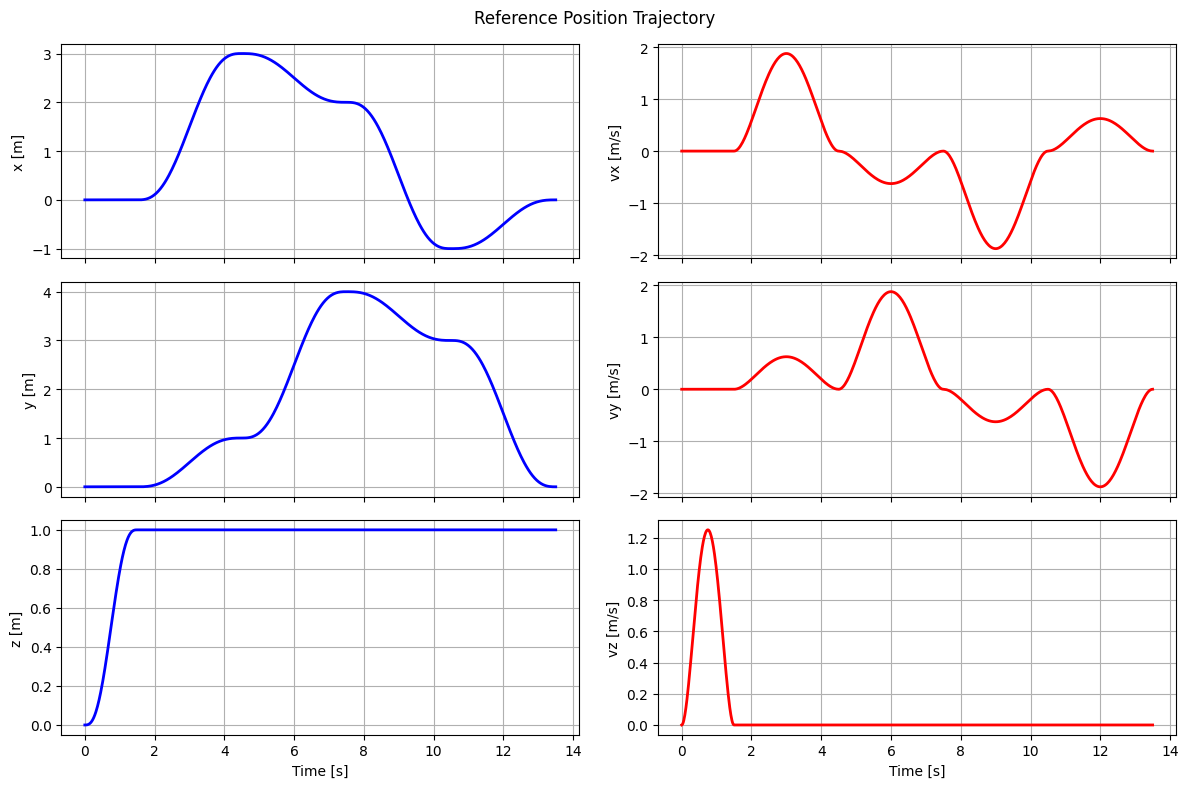

In [23]:
# Plot reference trajectory
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

labels_pos = ['x [m]', 'y [m]', 'z [m]']
labels_vel = ['vx [m/s]', 'vy [m/s]', 'vz [m/s]']
# Negate z for display (model uses NED internally, z-down; we show z-up)
z_sign = [1, 1, -1]

for i in range(3):
    axes[i, 0].plot(t_eval, z_sign[i] * p_ref[:, i], 'b-', linewidth=2)
    axes[i, 0].set_ylabel(labels_pos[i])
    axes[i, 0].grid(True)
    
    axes[i, 1].plot(t_eval, z_sign[i] * v_ref[:, i], 'r-', linewidth=2)
    axes[i, 1].set_ylabel(labels_vel[i])
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel('Time [s]')
axes[-1, 1].set_xlabel('Time [s]')
fig.suptitle('Reference Position Trajectory')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ref_trajectory.png", dpi=150)
plt.show()

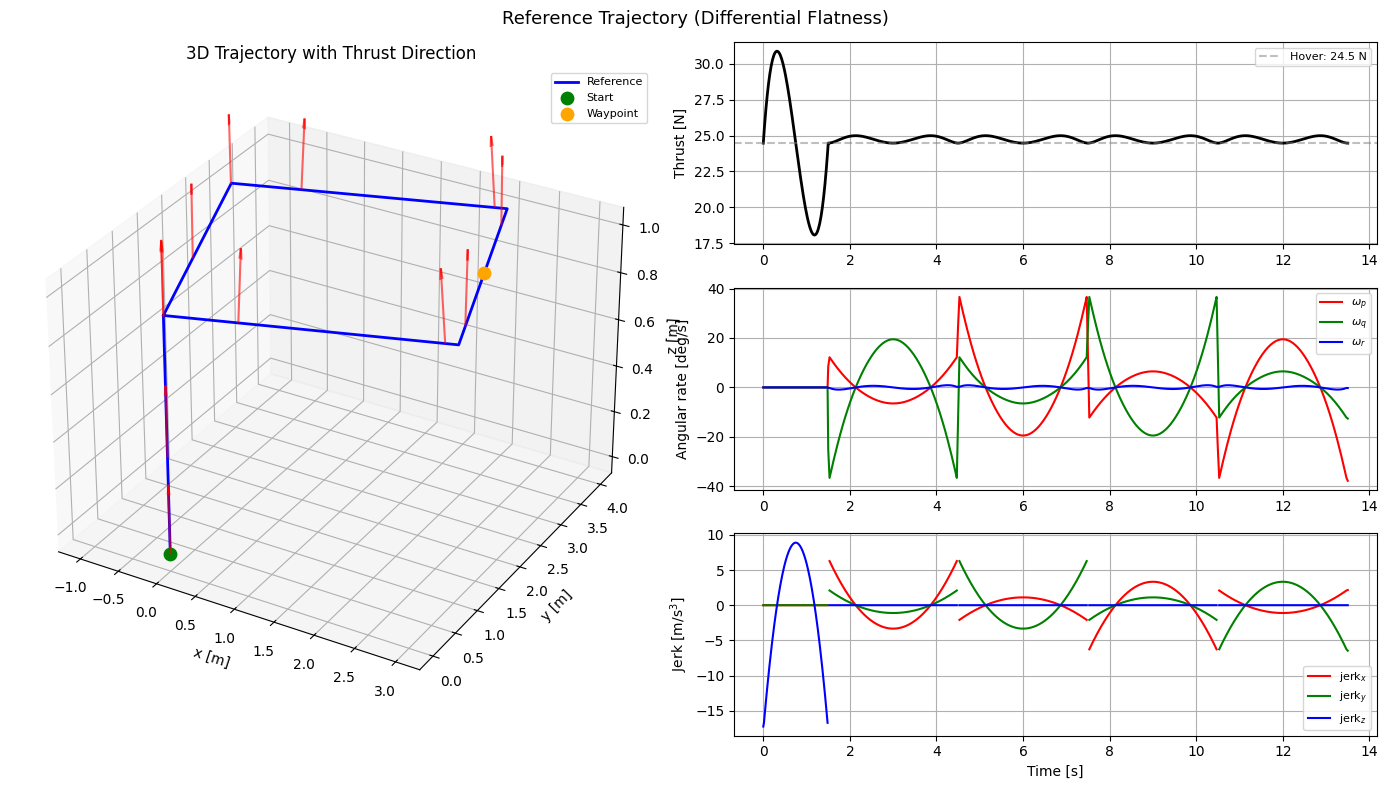

In [24]:
# 3D reference trajectory with thrust direction and angular velocity
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 8))

# 3D trajectory with thrust vectors (z-up: negate pz)
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot(p_ref[:, 0], p_ref[:, 1], -p_ref[:, 2], 'b-', linewidth=2, label='Reference')
ax3d.scatter(*p_ref[0, :2], -p_ref[0, 2], color='g', s=80, zorder=5, label='Start')
ax3d.scatter(*p_ref[len(t_eval)//2, :2], -p_ref[len(t_eval)//2, 2],
             color='orange', s=80, zorder=5, label='Waypoint')

# Show thrust direction at sampled points
# Thrust = -body_z in NED; for z-up display, negate z component
n_arrows = 12
arrow_idx = np.round(np.linspace(0, len(t_eval)-1, n_arrows)).astype(int)
R_ref = flat_ref['R_ref']
for k in arrow_idx:
    thrust_dir = -R_ref[k, :, 2]  # thrust = negative body Z in NED
    scale = 0.3
    ax3d.quiver(p_ref[k, 0], p_ref[k, 1], -p_ref[k, 2],
                scale*thrust_dir[0], scale*thrust_dir[1], -scale*thrust_dir[2],
                color='r', alpha=0.6, arrow_length_ratio=0.15)

ax3d.set_xlabel('x [m]')
ax3d.set_ylabel('y [m]')
ax3d.set_zlabel('z [m]')
ax3d.set_title('3D Trajectory with Thrust Direction')
ax3d.legend(fontsize=8)

# Flatness outputs: thrust and angular velocity vs time
ax_T = fig.add_subplot(322)
ax_T.plot(t_eval, flat_ref['T_ref'], 'k-', linewidth=2)
ax_T.axhline(mass * g, color='gray', linestyle='--', alpha=0.5, label=f'Hover: {mass*g:.1f} N')
ax_T.set_ylabel('Thrust [N]')
ax_T.legend(fontsize=8)
ax_T.grid(True)

ax_w = fig.add_subplot(324, sharex=ax_T)
for i, (label, color) in enumerate(zip(['p', 'q', 'r'], ['r', 'g', 'b'])):
    ax_w.plot(t_eval, np.rad2deg(omega_ref[:, i]), color=color, linewidth=1.5, label=f'$\\omega_{label}$')
ax_w.set_ylabel('Angular rate [deg/s]')
ax_w.legend(fontsize=8)
ax_w.grid(True)

ax_j = fig.add_subplot(326, sharex=ax_T)
for i, (label, color) in enumerate(zip(['x', 'y', 'z'], ['r', 'g', 'b'])):
    ax_j.plot(t_eval, jerk_ref[:, i], color=color, linewidth=1.5, label=f'jerk$_{label}$')
ax_j.set_ylabel('Jerk [m/s$^3$]')
ax_j.set_xlabel('Time [s]')
ax_j.legend(fontsize=8)
ax_j.grid(True)

fig.suptitle('Reference Trajectory (Differential Flatness)', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ref_trajectory_3d.png", dpi=150)
plt.show()

In [25]:
from cp_reach.reachability import (
    partition_states,
    se23_drift_matrix,
    solve_disturbance_LMI,
    solve_time_varying_polytopic_lmi,
    compute_state_bounds,
)

# Identify Lie group vs remaining states
partition = partition_states(ss.get_state_names(), lie_spec)
print(f"Lie group states ({len(partition['lie_group'])}): {partition['lie_group']}")
print(f"Remaining (not in Lie algebra): {partition['remaining']}")

# Sample trajectory at NUM_SAMPLES points for the LMI
idx = np.round(np.linspace(0, len(t_eval) - 1, NUM_SAMPLES)).astype(int)
times_sample = t_eval[idx]
omega_refs_sample = omega_ref[idx]
v_refs_sample = v_ref[idx]
a_refs_sample = a_body_ref[idx]

# Inertia
Ixx, Iyy, Izz = params['Ixx'], params['Iyy'], params['Izz']

# Inner loop gains (rate PD) — Layer 1
controller_gains = {k: params[k] for k in ['Kw_x', 'Kw_y', 'Kw_z', 'Kr_x', 'Kr_y', 'Kr_z']}
Kw_x, Kw_y, Kw_z = params['Kw_x'], params['Kw_y'], params['Kw_z']

# Outer loop gains — Layer 2 (per-axis)
Kp_se23 = np.array([params['Kp_px'] * params['Kp_vx'],
                     params['Kp_py'] * params['Kp_vy'],
                     params['Kp_pz'] * params['Kp_vz']])
Kd_se23 = np.array([params['Kp_vx'], params['Kp_vy'], params['Kp_vz']])
Kpq_se23 = np.array([params['Kr_x'], params['Kr_y'], params['Kr_z']])
Ki_se23 = np.array([params['Ki_vx'], params['Ki_vy'], params['Ki_vz']])

# Build PD controller matrices for 9x9 SE_2(3) system (no integrator)
# B0 @ K_pd maps Lie algebra error to closed-loop PD feedback
B0 = np.zeros((9, 6))
B0[3:6, 0:3] = np.eye(3)  # acceleration -> velocity block
B0[6:9, 3:6] = np.eye(3)  # angular rate -> rotation block

K_pd = np.zeros((6, 9))
K_pd[0:3, 0:3] = np.diag(Kp_se23)   # xi_p -> accel command
K_pd[0:3, 3:6] = np.diag(Kd_se23)   # xi_v -> accel command
K_pd[3:6, 6:9] = np.diag(Kpq_se23)  # xi_R -> rate command

BK_pd = B0 @ K_pd

# Disturbance input matrices (two channels):
#   Channel 1: omega error from Layer 1 -> rotation block (rows 6-8)
#   Channel 2: integrator error z_tilde -> velocity block (rows 3-5) via Ki gains
B_omega = np.zeros((9, 3))
B_omega[6:9, :] = np.eye(3)

B_int = np.zeros((9, 3))
B_int[3:6, :] = np.diag(Ki_se23)  # Ki * z_tilde enters velocity dynamics

B_dist = np.hstack([B_omega, B_int])  # (9, 6) combined disturbance matrix

# Per-channel disturbance bounds: [omega_1, omega_2, omega_3, z_1, z_2, z_3]
# (filled in after Layer 1 solves for omega_bounds)

print(f"\nLayer 1: 3 states (omega error), 8 vertices (time-invariant)")
print(f"Layer 2: 9D SE_2(3) error, integrator as separate disturbance channel")
print(f"  PD gains: Kp={Kp_se23}, Kd={Kd_se23}, Kpq={Kpq_se23}")
print(f"  Ki gains (disturbance channel): Ki={Ki_se23}")

Lie group states (15): ['px', 'py', 'pz', 'vx', 'vy', 'vz', 'R11', 'R12', 'R13', 'R21', 'R22', 'R23', 'R31', 'R32', 'R33']
Remaining (not in Lie algebra): ['omega_x', 'omega_y', 'omega_z', 'vel_err_ix', 'vel_err_iy', 'vel_err_iz']

Layer 1: 3 states (omega error), 8 vertices (time-invariant)
Layer 2: 9D SE_2(3) error, integrator as separate disturbance channel
  PD gains: Kp=[0.09 0.09 0.24], Kd=[0.45 0.45 0.6 ], Kpq=[1.  1.  0.8]
  Ki gains (disturbance channel): Ki=[0.1 0.1 0.1]


### Layer 1: Rotational Dynamics (Time-Invariant Polytopic LMI, 8 vertices)

Euler's equations linearized around the reference. The gyroscopic coupling
Jacobian is linear in omega, so we bound it over the entire trajectory by
taking `max(|omega_ref|)` per axis. The 8 corners of this box give the
polytopic vertices for a single time-invariant LMI.

Since the cascaded architecture passes only the worst-case (scalar) omega
bound to Layer 2, a time-varying Layer 1 would provide no benefit.

In [26]:
# # --- Option A: Time-varying polytopic LMI (tighter per-time-point, but unused by cascade) ---
# from cp_reach.reachability import euler_equation_jacobians

# OMEGA_ERROR_BOUND = 0.5  # rad/s, polytopic box around each omega_ref(t)

# J_omega_vertices = euler_equation_jacobians(
#     omega_refs_sample, OMEGA_ERROR_BOUND,
#     Ixx, Iyy, Izz, controller_gains,
# )

# layer1_tv_result = solve_time_varying_polytopic_lmi(
#     J_omega_vertices, np.eye(3), times_sample.tolist(),
#     polynomial_degree=NUM_SAMPLES,
#     verbose=True,
# )

# omega_bounds_tv = compute_state_bounds(
#     layer1_tv_result['M_coefs'],
#     layer1_tv_result['mu_physical'],
#     D_GYRO,
#     times_sample.tolist(),
# )['bounds_max']

# print(f"Time-varying Layer 1: alpha={layer1_tv_result['alpha']:.4f}, omega bounds={omega_bounds_tv}")

In [27]:
# Worst-case omega across the entire trajectory
omega_wc = np.max(np.abs(omega_ref), axis=0)

# Build 8 polytopic vertices: corners of [-omega_wc, +omega_wc]^3
A_list_omega = []
Kw_x, Kw_y, Kw_z = params['Kw_x'], params['Kw_y'], params['Kw_z']
for s1 in [-1, 1]:
    for s2 in [-1, 1]:
        for s3 in [-1, 1]:
            ox = s1 * omega_wc[0]
            oy = s2 * omega_wc[1]
            oz = s3 * omega_wc[2]
            A_list_omega.append(np.array([
                [-Kw_x, (Iyy - Izz) * oz / Ixx, (Iyy - Izz) * oy / Ixx],
                [(Izz - Ixx) * oz / Iyy, -Kw_y, (Izz - Ixx) * ox / Iyy],
                [(Ixx - Iyy) * oy / Izz, (Ixx - Iyy) * ox / Izz, -Kw_z],
            ]))

# Solve time-invariant polytopic LMI
layer1_result = solve_disturbance_LMI(A_list_omega, np.eye(3), w_max=D_GYRO)

# Per-axis bounds from ellipsoid {e : e^T P e <= c}
P_omega_inv = np.linalg.inv(layer1_result['P'])
c_omega = layer1_result['cost']  # = sum(mu_i * w_i^2)
omega_bounds = np.sqrt(c_omega * np.diag(P_omega_inv))

print(f"Layer 1: alpha={layer1_result['alpha']:.4f}, omega bounds={omega_bounds}")

Layer 1: alpha=0.9997, omega bounds=[0.13090163 0.13090237 0.13089961]


### Layer 2: SE₂(3) Kinematics (9×9 Log-Linear LMI)

The kinematic subsystem is exact log-linear on SE₂(3). The error dynamics are:

$$\dot{\xi} = A(t)\,\xi + B_{\tilde{n}}\,\tilde{n} + B_{\tilde{z}}\,\tilde{z}$$

where:
- $\xi = [\xi_p, \xi_v, \xi_R] \in \mathbb{R}^9$ is the Lie algebra error
- $A(t) = -\mathrm{ad}_{\bar{n}} + A_C - B_0 K_{\mathrm{PD}}$ (9×9, PD feedback only)
- $\tilde{n}$: omega error from Layer 1 → rotation block
- $\tilde{z}$: integrator error → velocity block (via $K_i$ gains)

Two disturbance channels with separate bounds: $\|\tilde{n}\| \leq d_\omega$,
$\|\tilde{z}\| \leq d_z$.

- **Option A** (fastest): Single worst-case A matrix — 1 vertex
- **Option B** (moderate): Sampled A(t) as polytopic vertices — N vertices, time-invariant P
- **Option C** (tightest): Time-varying polynomial Lyapunov M(t) — adapts along trajectory

In [28]:
# --- Option A: Single worst-case A matrix (fastest, most conservative) ---
# Use max(|v_ref|), max(|a_body_ref|), max(|omega_ref|) per axis
v_wc = np.max(np.abs(v_ref), axis=0)
a_wc = np.max(np.abs(a_body_ref), axis=0)
omega_wc_kin = np.max(np.abs(omega_ref), axis=0)

A_drift_wc = se23_drift_matrix(v_wc, a_wc, omega_wc_kin)
A_cl_wc = A_drift_wc - BK_pd

# Per-channel disturbance bounds
w_max_vec = np.concatenate([omega_bounds, Z_BOUND * np.ones(3)])

layer2_wc_result = solve_disturbance_LMI([A_cl_wc], B_dist, w_max=w_max_vec)

P_wc_inv = np.linalg.inv(layer2_wc_result['P'])
c_wc = layer2_wc_result['cost']
xi_bounds_wc = np.sqrt(c_wc * np.diag(P_wc_inv))

xi_names = ['xi_px', 'xi_py', 'xi_pz',
            'xi_vx', 'xi_vy', 'xi_vz',
            'xi_Rx', 'xi_Ry', 'xi_Rz']

print(f"Layer 2 (worst-case, 1 vertex): alpha={layer2_wc_result['alpha']:.4f}")
for name, bound in zip(xi_names, xi_bounds_wc):
    print(f"  {name}: +/-{bound:.6f}")

Layer 2 (worst-case, 1 vertex): alpha=0.5210
  xi_px: +/-5.996199
  xi_py: +/-6.731895
  xi_pz: +/-6.367953
  xi_vx: +/-4.119338
  xi_vy: +/-4.237402
  xi_vz: +/-4.209076
  xi_Rx: +/-0.269581
  xi_Ry: +/-0.275695
  xi_Rz: +/-0.297977


In [ ]:
# # --- Option B: Sampled A(t) as polytopic vertices (moderate) ---
# # Build closed-loop A_cl(t) at each sample point
# A_list_kin = []
# for k in range(len(times_sample)):
#     A_drift_k = se23_drift_matrix(v_refs_sample[k], a_refs_sample[k], omega_refs_sample[k])
#     A_list_kin.append(A_drift_k - BK_pd)

# w_max_vec = np.concatenate([omega_bounds, Z_BOUND * np.ones(3)])

# layer2_ti_result = solve_disturbance_LMI(A_list_kin, B_dist, w_max=w_max_vec)

# P_xi_inv = np.linalg.inv(layer2_ti_result['P'])
# c_xi = layer2_ti_result['cost']
# xi_bounds_ti = np.sqrt(c_xi * np.diag(P_xi_inv))

# print(f"Layer 2 (sampled, {len(A_list_kin)} vertices): alpha={layer2_ti_result['alpha']:.4f}")
# for name, bound in zip(xi_names, xi_bounds_ti):
#     print(f"  {name}: +/-{bound:.6f}")

Layer 2 (sampled, 20 vertices): alpha=0.4921
  xi_px: +/-10.923362
  xi_py: +/-10.839820
  xi_pz: +/-8.758624
  xi_vx: +/-4.327748
  xi_vy: +/-4.274137
  xi_vz: +/-4.374595
  xi_Rx: +/-0.302765
  xi_Ry: +/-0.309838
  xi_Rz: +/-0.397774


In [30]:
# # --- Option C: Time-varying polynomial Lyapunov (tightest, slowest) ---
# # Build A(t) as single-vertex-per-time for the time-varying solver
# A_kinematic = []
# for k in range(len(times_sample)):
#     A_drift_k = se23_drift_matrix(v_refs_sample[k], a_refs_sample[k], omega_refs_sample[k])
#     A_kinematic.append([A_drift_k - BK_pd])  # single vertex per time

# w_max_vec = np.concatenate([omega_bounds, Z_BOUND * np.ones(3)])
# d_combined = np.linalg.norm(w_max_vec)

# layer2_result = solve_time_varying_polytopic_lmi(
#     A_kinematic, B_dist, times_sample.tolist(),
#     polynomial_degree=NUM_SAMPLES,
#     verbose=True,
# )

# xi_bounds_result = compute_state_bounds(
#     layer2_result['M_coefs'],
#     layer2_result['mu_physical'],
#     d_combined,
#     times_sample.tolist(),
# )
# xi_bounds = xi_bounds_result['bounds_max']

# print(f"\nLayer 2 (time-varying): alpha={layer2_result['alpha']:.4f}")
# for name, bound in zip(xi_names, xi_bounds):
#     print(f"  {name}: +/-{bound:.6f}")

## Simulate with Disturbance Sweep

Build a numerical dynamics function from the Modelica model and simulate
with square-wave gyro bias disturbances at varied frequencies.

In [31]:
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import sympy as sp

# Build numerical dynamics function from symbolic model
full_dynamics = ss.f + ss.Bu
param_subs = {sp.Symbol(k): v for k, v in params.items()}
dynamics_with_params = full_dynamics.subs(param_subs)

dynamics_func = sp.lambdify(
    [ss.state_symbols, ss.input_symbols],
    dynamics_with_params,
    modules='numpy',
)

# Build reference interpolators
input_names = ss.get_input_names()
R_ref = flat_ref['R_ref']
T_ref_val = flat_ref['T_ref']

# Interpolators for reference trajectory
p_interp = [interp1d(t_eval, p_ref[:, i], fill_value='extrapolate') for i in range(3)]
v_interp = [interp1d(t_eval, v_ref[:, i], fill_value='extrapolate') for i in range(3)]
R_interp = [[interp1d(t_eval, R_ref[:, i, j], fill_value='extrapolate')
             for j in range(3)] for i in range(3)]
omega_interp = [interp1d(t_eval, omega_ref[:, i], fill_value='extrapolate') for i in range(3)]
T_interp = interp1d(t_eval, T_ref_val, fill_value='extrapolate')

def get_inputs(t, d_p=0.0, d_q=0.0, d_r=0.0):
    """Build input vector for the quadrotor model at time t."""
    u = np.zeros(len(input_names))
    # Position reference
    for i, name in enumerate(['px_ref', 'py_ref', 'pz_ref']):
        u[input_names.index(name)] = float(p_interp[i](t))
    # Velocity reference
    for i, name in enumerate(['vx_ref', 'vy_ref', 'vz_ref']):
        u[input_names.index(name)] = float(v_interp[i](t))
    # Rotation reference (flatten 3x3)
    for i in range(3):
        for j in range(3):
            name = f'R{i+1}{j+1}_ref'
            u[input_names.index(name)] = float(R_interp[i][j](t))
    # Angular velocity reference
    for i, name in enumerate(['omega_x_ref', 'omega_y_ref', 'omega_z_ref']):
        u[input_names.index(name)] = float(omega_interp[i](t))
    # Feedforward thrust and moments
    u[input_names.index('T_ff')] = float(T_interp(t))
    # Mx_ff, My_ff, Mz_ff = 0 (no feedforward moments)
    # Disturbances
    u[input_names.index('d_p')] = d_p
    u[input_names.index('d_q')] = d_q
    u[input_names.index('d_r')] = d_r
    return u

print(f'Dynamics function built: {len(ss.state_symbols)} states, {len(input_names)} inputs')
print(f'Input names: {input_names}')

Dynamics function built: 21 states, 25 inputs
Input names: ['px_ref', 'py_ref', 'pz_ref', 'vx_ref', 'vy_ref', 'vz_ref', 'R11_ref', 'R12_ref', 'R13_ref', 'R21_ref', 'R22_ref', 'R23_ref', 'R31_ref', 'R32_ref', 'R33_ref', 'omega_x_ref', 'omega_y_ref', 'omega_z_ref', 'T_ff', 'Mx_ff', 'My_ff', 'Mz_ff', 'd_p', 'd_q', 'd_r']


In [32]:
# Initial state: on the reference trajectory
state_names = ss.get_state_names()
x0 = np.zeros(len(state_names))

# Set position to reference start
x0[state_names.index('px')] = p_ref[0, 0]
x0[state_names.index('py')] = p_ref[0, 1]
x0[state_names.index('pz')] = p_ref[0, 2]

# Set rotation matrix to identity (hover)
x0[state_names.index('R11')] = 1.0
x0[state_names.index('R22')] = 1.0
x0[state_names.index('R33')] = 1.0

t_span = (t_eval[0], t_eval[-1])

# Nominal simulation (no disturbance)
def nominal_ode(t, state):
    inputs = get_inputs(t)
    return np.array(dynamics_func(state, inputs)).flatten()

print("Running nominal simulation...")
nom_sol = solve_ivp(nominal_ode, t_span, x0, t_eval=t_eval, method='RK45',
                     rtol=1e-8, atol=1e-10)

print(f"Nominal simulation: {nom_sol.status} ({nom_sol.message})")
print(f"  Final position: [{nom_sol.y[state_names.index('px'), -1]:.4f}, "
      f"{nom_sol.y[state_names.index('py'), -1]:.4f}, "
      f"{nom_sol.y[state_names.index('pz'), -1]:.4f}]")

Running nominal simulation...
Nominal simulation: 0 (The solver successfully reached the end of the integration interval.)
  Final position: [0.6003, -2.7371, -20.8209]


In [33]:
# Disturbance sweep: square-wave gyro bias on all 3 axes
frequencies = np.arange(0.1, 1.0, 0.2)  # 5 frequencies
n_phases = 6
n_axes = 3  # disturbance on each axis independently + combined

print(f"Sweeping {len(frequencies)} freq x {n_phases} phases x {n_axes+1} axis configs "
      f"= {len(frequencies) * n_phases * (n_axes + 1)} simulations")

disturbed_trajectories = []

for freq in frequencies:
    period = 1.0 / freq
    phases = np.linspace(0, period, n_phases, endpoint=False)
    
    for phase in phases:
        def make_square(t, period=period, phase=phase):
            t_shifted = t + phase
            return D_GYRO if ((t_shifted % period) / period) < 0.5 else -D_GYRO
        
        # Disturbance on each axis independently
        for axis_config in range(n_axes + 1):
            def disturbed_ode(t, state, axis_config=axis_config):
                d_val = make_square(t)
                if axis_config == 0:
                    d = [d_val, 0, 0]
                elif axis_config == 1:
                    d = [0, d_val, 0]
                elif axis_config == 2:
                    d = [0, 0, d_val]
                else:
                    d = [d_val, d_val, d_val]  # all axes
                inputs = get_inputs(t, d_p=d[0], d_q=d[1], d_r=d[2])
                return np.array(dynamics_func(state, inputs)).flatten()
            
            sol = solve_ivp(disturbed_ode, t_span, x0, t_eval=t_eval,
                           method='RK45', rtol=1e-8, atol=1e-10)
            if sol.status == 0:
                disturbed_trajectories.append(sol.y)

print(f"Completed {len(disturbed_trajectories)} simulations")

Sweeping 5 freq x 6 phases x 4 axis configs = 120 simulations
Completed 120 simulations


## Plot Position Flowpipe

Show disturbed trajectories with the reachable set bounds from the cascaded LMI.
The xi_p bounds from Layer 2 give the position error in the Lie algebra,
which for small errors approximates the world-frame position error.

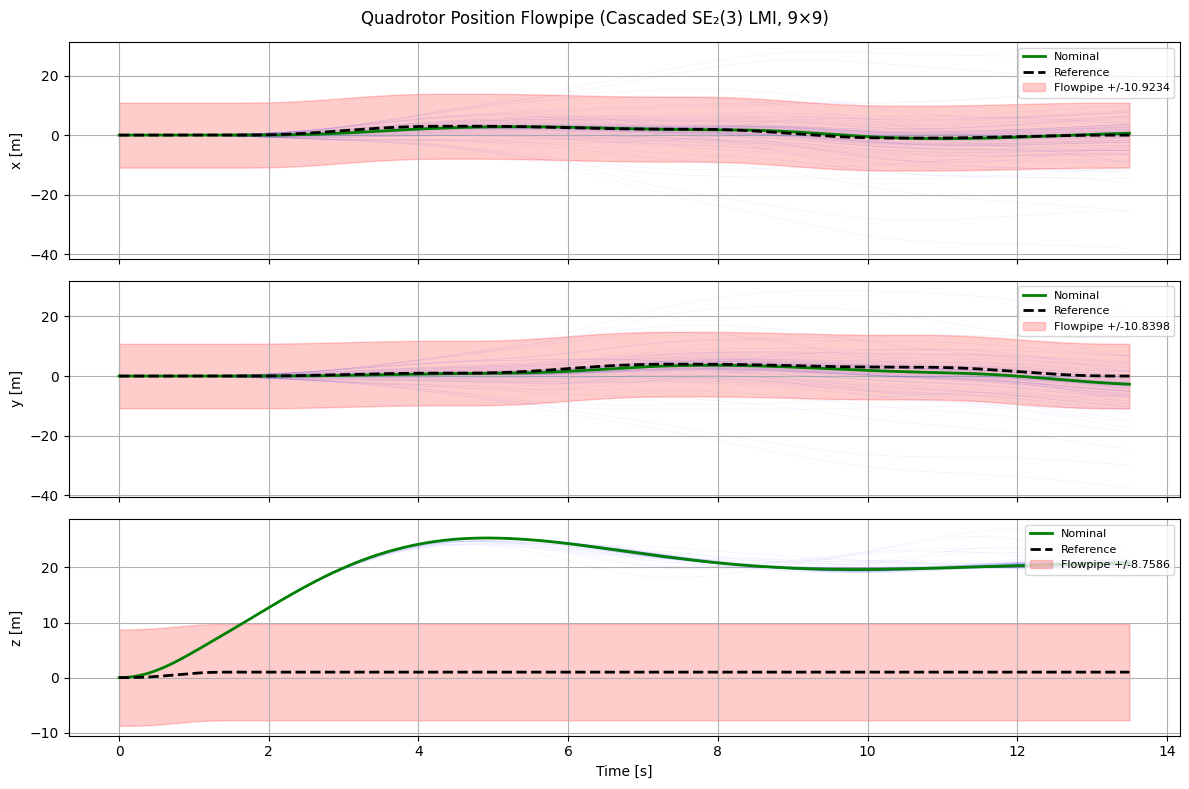

In [35]:
# Extract position indices
idx_px = state_names.index('px')
idx_py = state_names.index('py')
idx_pz = state_names.index('pz')
idx_vx = state_names.index('vx')
idx_vy = state_names.index('vy')
idx_vz = state_names.index('vz')
idx_ox = state_names.index('omega_x')
idx_oy = state_names.index('omega_y')
idx_oz = state_names.index('omega_z')

# Use whichever Layer 2 result is available (Option C > B > A)
if 'xi_bounds' not in dir():
    xi_bounds = xi_bounds_ti if 'xi_bounds_ti' in dir() else xi_bounds_wc

# Bounds from LMI layers (9D SE_2(3) error)
pos_bounds = xi_bounds[0:3]  # [xi_px, xi_py, xi_pz]
vel_bounds = xi_bounds[3:6]  # [xi_vx, xi_vy, xi_vz]
rot_bounds = xi_bounds[6:9]  # [xi_Rx, xi_Ry, xi_Rz]

# z-up display: negate z for plotting
z_sign = [1, 1, -1]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
pos_labels = ['x [m]', 'y [m]', 'z [m]']
pos_indices = [idx_px, idx_py, idx_pz]

for i, (ax, label, idx_s) in enumerate(zip(axes, pos_labels, pos_indices)):
    # Disturbed trajectories
    for traj in disturbed_trajectories:
        ax.plot(t_eval, z_sign[i] * traj[idx_s], 'b-', alpha=0.05, linewidth=0.5)
    
    # Nominal
    ax.plot(t_eval, z_sign[i] * nom_sol.y[idx_s], 'g-', linewidth=2, label='Nominal')
    
    # Reference
    ax.plot(t_eval, z_sign[i] * p_ref[:, i], 'k--', linewidth=2, label='Reference')
    
    # Flowpipe bounds
    p_disp = z_sign[i] * p_ref[:, i]
    ax.fill_between(t_eval, p_disp - pos_bounds[i], p_disp + pos_bounds[i],
                    color='r', alpha=0.2, label=f'Flowpipe +/-{pos_bounds[i]:.4f}')
    
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel('Time [s]')
fig.suptitle('Quadrotor Position Flowpipe (Cascaded SE₂(3) LMI, 9×9)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/position_flowpipe.png", dpi=150)
plt.show()

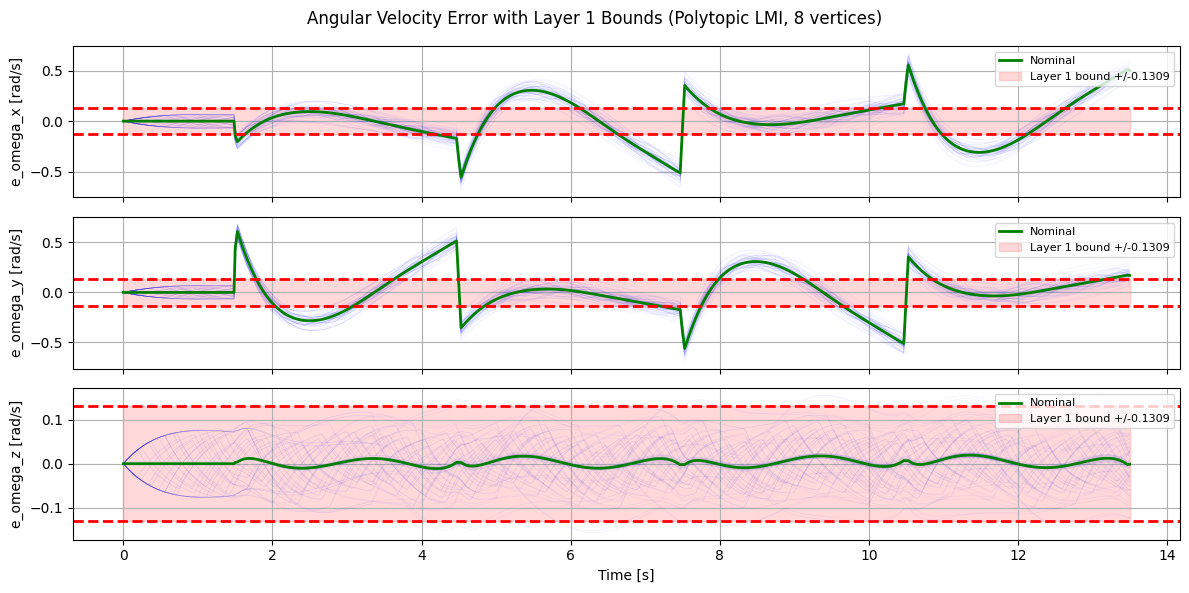

In [36]:
# Plot angular velocity error with Layer 1 bounds
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
omega_labels = ['omega_x [rad/s]', 'omega_y [rad/s]', 'omega_z [rad/s]']
omega_indices = [idx_ox, idx_oy, idx_oz]

for i, (ax, label, idx_s) in enumerate(zip(axes, omega_labels, omega_indices)):
    # Compute error: omega - omega_ref
    omega_ref_i = interp1d(t_eval, omega_ref[:, i], fill_value='extrapolate')
    
    for traj in disturbed_trajectories:
        e_omega = traj[idx_s] - omega_ref_i(t_eval)
        ax.plot(t_eval, e_omega, 'b-', alpha=0.05, linewidth=0.5)
    
    # Nominal error
    e_nom = nom_sol.y[idx_s] - omega_ref_i(t_eval)
    ax.plot(t_eval, e_nom, 'g-', linewidth=2, label='Nominal')
    
    # Layer 1 bounds
    ax.axhline(omega_bounds[i], color='r', linestyle='--', linewidth=2)
    ax.axhline(-omega_bounds[i], color='r', linestyle='--', linewidth=2)
    ax.fill_between(t_eval, -omega_bounds[i], omega_bounds[i],
                    color='r', alpha=0.15, label=f'Layer 1 bound +/-{omega_bounds[i]:.4f}')
    
    ax.set_ylabel(f'e_{label}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel('Time [s]')
fig.suptitle('Angular Velocity Error with Layer 1 Bounds (Polytopic LMI, 8 vertices)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/omega_error.png", dpi=150)
plt.show()

## 3D Position Flowpipe Visualization

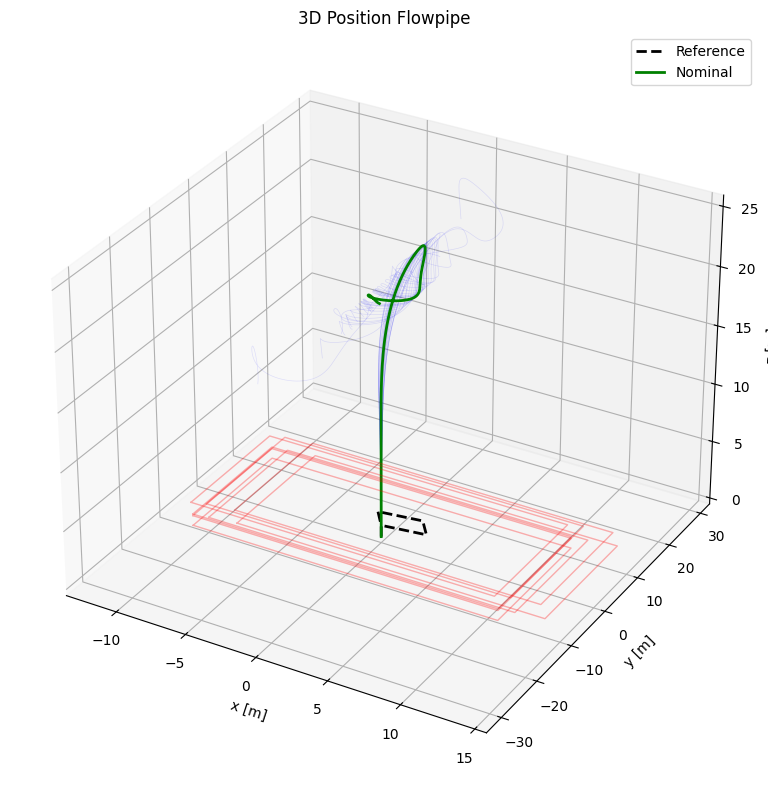

In [37]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Disturbed trajectories (z-up: negate pz)
for traj in disturbed_trajectories[::4]:  # plot every 4th for clarity
    ax.plot(traj[idx_px], traj[idx_py], -traj[idx_pz],
            'b-', alpha=0.1, linewidth=0.5)

# Reference trajectory
ax.plot(p_ref[:, 0], p_ref[:, 1], -p_ref[:, 2],
        'k--', linewidth=2, label='Reference')

# Nominal
ax.plot(nom_sol.y[idx_px], nom_sol.y[idx_py], -nom_sol.y[idx_pz],
        'g-', linewidth=2, label='Nominal')

# Flowpipe tube: show cross-section rectangles at a few times
n_ellipses = 8
ellipse_indices = np.round(np.linspace(0, len(t_eval)-1, n_ellipses)).astype(int)

for ei in ellipse_indices:
    center = [p_ref[ei, 0], p_ref[ei, 1], -p_ref[ei, 2]]
    r = pos_bounds
    corners_x = center[0] + np.array([-1, 1, 1, -1, -1]) * r[0]
    corners_y = center[1] + np.array([-1, -1, 1, 1, -1]) * r[1]
    ax.plot(corners_x, corners_y, [center[2]]*5, 'r-', alpha=0.3, linewidth=1)

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_title('3D Position Flowpipe')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/position_3d.png", dpi=150)
plt.show()

## Velocity and Attitude Error Bounds

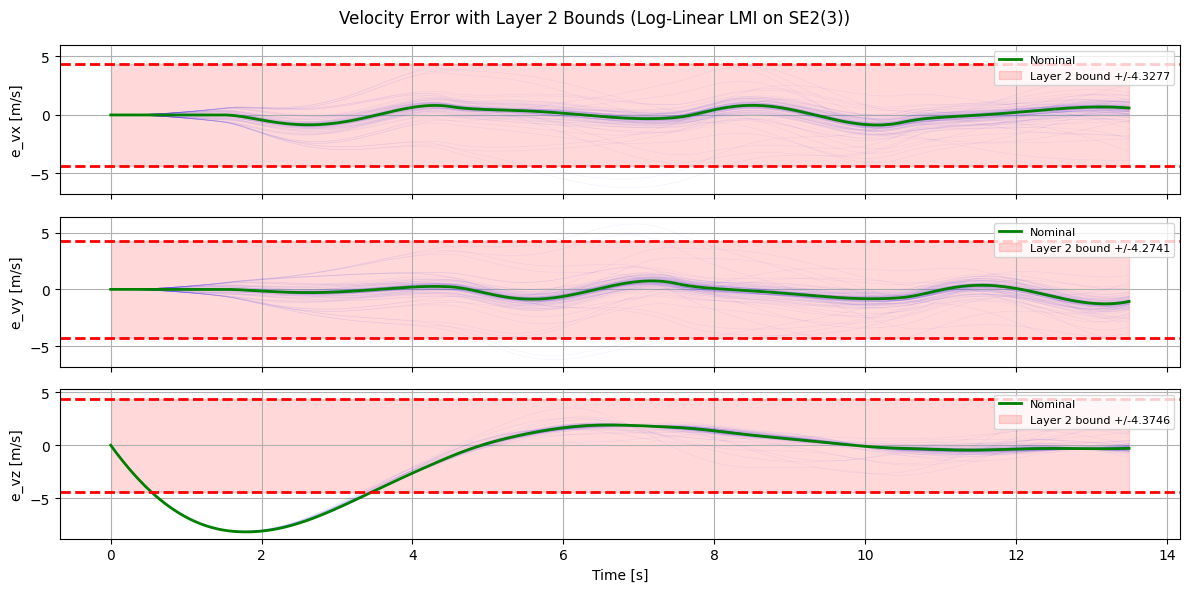

In [38]:
# Plot velocity error with Layer 2 bounds
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
vel_labels = ['vx [m/s]', 'vy [m/s]', 'vz [m/s]']
vel_indices = [idx_vx, idx_vy, idx_vz]

for i, (ax, label, idx_s) in enumerate(zip(axes, vel_labels, vel_indices)):
    vel_ref_i = interp1d(t_eval, v_ref[:, i], fill_value='extrapolate')
    
    for traj in disturbed_trajectories:
        e_vel = traj[idx_s] - vel_ref_i(t_eval)
        ax.plot(t_eval, e_vel, 'b-', alpha=0.05, linewidth=0.5)
    
    e_nom = nom_sol.y[idx_s] - vel_ref_i(t_eval)
    ax.plot(t_eval, e_nom, 'g-', linewidth=2, label='Nominal')
    
    ax.axhline(vel_bounds[i], color='r', linestyle='--', linewidth=2)
    ax.axhline(-vel_bounds[i], color='r', linestyle='--', linewidth=2)
    ax.fill_between(t_eval, -vel_bounds[i], vel_bounds[i],
                    color='r', alpha=0.15, label=f'Layer 2 bound +/-{vel_bounds[i]:.4f}')
    
    ax.set_ylabel(f'e_{label}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel('Time [s]')
fig.suptitle('Velocity Error with Layer 2 Bounds (Log-Linear LMI on SE2(3))')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/velocity_error.png", dpi=150)
plt.show()

## Summary

In [ ]:
# Validation: check if all simulated trajectories stay within bounds
max_errors = {
    'position': np.zeros(3),
    'velocity': np.zeros(3),
    'omega': np.zeros(3),
}

for traj in disturbed_trajectories:
    for i, idx_s in enumerate([idx_px, idx_py, idx_pz]):
        ref_i = interp1d(t_eval, p_ref[:, i], fill_value='extrapolate')
        e = np.max(np.abs(traj[idx_s] - ref_i(t_eval)))
        max_errors['position'][i] = max(max_errors['position'][i], e)
    
    for i, idx_s in enumerate([idx_vx, idx_vy, idx_vz]):
        ref_i = interp1d(t_eval, v_ref[:, i], fill_value='extrapolate')
        e = np.max(np.abs(traj[idx_s] - ref_i(t_eval)))
        max_errors['velocity'][i] = max(max_errors['velocity'][i], e)
    
    for i, idx_s in enumerate([idx_ox, idx_oy, idx_oz]):
        ref_i = interp1d(t_eval, omega_ref[:, i], fill_value='extrapolate')
        e = np.max(np.abs(traj[idx_s] - ref_i(t_eval)))
        max_errors['omega'][i] = max(max_errors['omega'][i], e)

print("=" * 70)
print("CASCADED REACHABILITY SUMMARY")
print("=" * 70)
print(f"\nModel: {MODEL_NAME}")
print(f"Trajectory: {T_total:.1f}s, {len(t_eval)} points")
print(f"Disturbance: gyro bias d = {D_GYRO} rad/s, integrator bound z = {Z_BOUND}")
print(f"Simulations: {len(disturbed_trajectories)}")

print(f"\nLayer 1 — Rotational dynamics (3 states, 8 vertices):")
print(f"  {'Axis':<10} {'Max error':>12} {'LMI bound':>12} {'Margin':>10}")
for i, name in enumerate(['omega_x', 'omega_y', 'omega_z']):
    margin = omega_bounds[i] - max_errors['omega'][i]
    status = 'OK' if margin >= 0 else 'EXCEEDED'
    print(f"  {name:<10} {max_errors['omega'][i]:>12.6f} {omega_bounds[i]:>12.6f} {margin:>10.6f} {status}")

print(f"\nLayer 2 — SE_2(3) kinematics (9 states, 2 disturbance channels):")
print(f"  {'Variable':<10} {'Max error':>12} {'LMI bound':>12} {'Margin':>10}")
for i, name in enumerate(['xi_px', 'xi_py', 'xi_pz']):
    margin = pos_bounds[i] - max_errors['position'][i]
    status = 'OK' if margin >= 0 else 'EXCEEDED'
    print(f"  {name:<10} {max_errors['position'][i]:>12.6f} {pos_bounds[i]:>12.6f} {margin:>10.6f} {status}")
for i, name in enumerate(['xi_vx', 'xi_vy', 'xi_vz']):
    margin = vel_bounds[i] - max_errors['velocity'][i]
    status = 'OK' if margin >= 0 else 'EXCEEDED'
    print(f"  {name:<10} {max_errors['velocity'][i]:>12.6f} {vel_bounds[i]:>12.6f} {margin:>10.6f} {status}")

print(f"\nComplexity comparison:")
print(f"  Cascaded:   Layer 1 = 8 vertices (3x3), Layer 2 = 1 vertex (9x9)")
print(f"  Monolithic: 2^12 = 4096 vertices (21x21)")